In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
movies = pd.read_csv("../data/raw/movies.csv")


In [5]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
movies.shape


(62423, 3)

In [7]:
movies.columns


Index(['movieId', 'title', 'genres'], dtype='str')

In [8]:
movies.isnull().sum()


movieId    0
title      0
genres     0
dtype: int64

In [9]:
movies["movieId"].duplicated().sum()


np.int64(0)

In [10]:
ratings = pd.read_csv("../data/raw/ratings.csv")

In [11]:
ratings.head()


,userId\tmovieId\trating\ttimestamp
0,1\t296\t5\t1147880044
1,1\t306\t3.5\t1147868817
2,1\t307\t5\t1147868828
3,1\t665\t5\t1147878820
4,1\t899\t3.5\t1147868510


In [12]:
ratings.shape


(1048575, 1)

In [14]:
ratings.isnull().sum()


userId\tmovieId\trating\ttimestamp    0
dtype: int64

In [17]:
ratings.columns


Index(['userId\tmovieId\trating\ttimestamp'], dtype='str')

In [18]:
ratings = pd.read_csv("../data/raw/ratings.csv", sep="\t")

In [19]:
ratings.columns


Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

In [20]:
ratings.duplicated(subset=["userId", "movieId"]).sum()

np.int64(0)

In [21]:
ratings["rating"].value_counts().sort_index()

rating
0.5     15139
1.0     31975
1.5     17494
2.0     69617
2.5     53093
3.0    207514
3.5    130755
4.0    280291
4.5     90051
5.0    152646
Name: count, dtype: int64

In [22]:
ratings["rating"].mean()

np.float64(3.5358081205445484)

In [23]:
ratings["userId"].nunique()

7045

In [24]:

ratings["movieId"].nunique()

22240

In [26]:
tags = pd.read_csv("../data/raw/tags.csv", sep="\t")

In [27]:
tags.head()

,"tagId,tag"
0,"1,007"
1,"2,007 (series)"
2,"3,18th century"
3,"4,1920s"
4,"5,1930s"


In [28]:
tags.shape

(1128, 1)

In [29]:
tags.columns

Index(['tagId,tag'], dtype='str')

In [30]:
tags.isnull().sum()

tagId,tag    0
dtype: int64

In [31]:
tags.duplicated().sum()

np.int64(0)

In [33]:
tags.columns


Index(['tagId,tag'], dtype='str')

In [34]:
tags = pd.read_csv("../data/raw/tags.csv")

In [35]:
tags.columns

Index(['tagId', 'tag'], dtype='str')

In [36]:
tags.duplicated().sum()

np.int64(0)

In [38]:
print(tags.columns.tolist())
print(tags.head())

['tagId', 'tag']
   tagId           tag
0      1           007
1      2  007 (series)
2      3  18th century
3      4         1920s
4      5         1930s


In [42]:
tags = pd.read_csv("../data/raw/tags.csv")

In [43]:
tags.columns

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='str')

In [44]:
tags["userId"].nunique()

14592

In [45]:
tags["tag"].nunique()

73050

In [46]:
tags["tag"].value_counts().head(20)

tag
sci-fi                8330
atmospheric           6516
action                5907
comedy                5702
surreal               5326
based on a book       5079
twist ending          4820
funny                 4738
visually appealing    4526
dystopia              4257
dark comedy           4026
BD-R                  3966
thought-provoking     3844
romance               3791
stylized              3728
quirky                3677
psychology            3625
woman director        3589
fantasy               3523
classic               3456
Name: count, dtype: int64

In [47]:
tags["userId"].value_counts().head(10)

userId
6550      183356
21096      20317
62199      13700
160540     12076
155146     11445
70092      10582
131347     10195
14116      10167
31047       8463
141263      7114
Name: count, dtype: int64

In [48]:
tags["movieId"].value_counts().head(10)

movieId
260       6180
79132     4767
296       4767
109487    3616
2959      3612
318       3597
2571      3573
356       2701
4226      2601
7361      2533
Name: count, dtype: int64

In [49]:
tags["tag_length"] = tags["tag"].astype(str).str.len()

In [50]:
tags["tag_length"].describe()

count    1.093344e+06
mean     1.066220e+01
std      5.461166e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      2.340000e+02
Name: tag_length, dtype: float64

In [51]:
top_tags = tags["tag"].value_counts().head(20)
top_tags

tag
sci-fi                8330
atmospheric           6516
action                5907
comedy                5702
surreal               5326
based on a book       5079
twist ending          4820
funny                 4738
visually appealing    4526
dystopia              4257
dark comedy           4026
BD-R                  3966
thought-provoking     3844
romance               3791
stylized              3728
quirky                3677
psychology            3625
woman director        3589
fantasy               3523
classic               3456
Name: count, dtype: int64

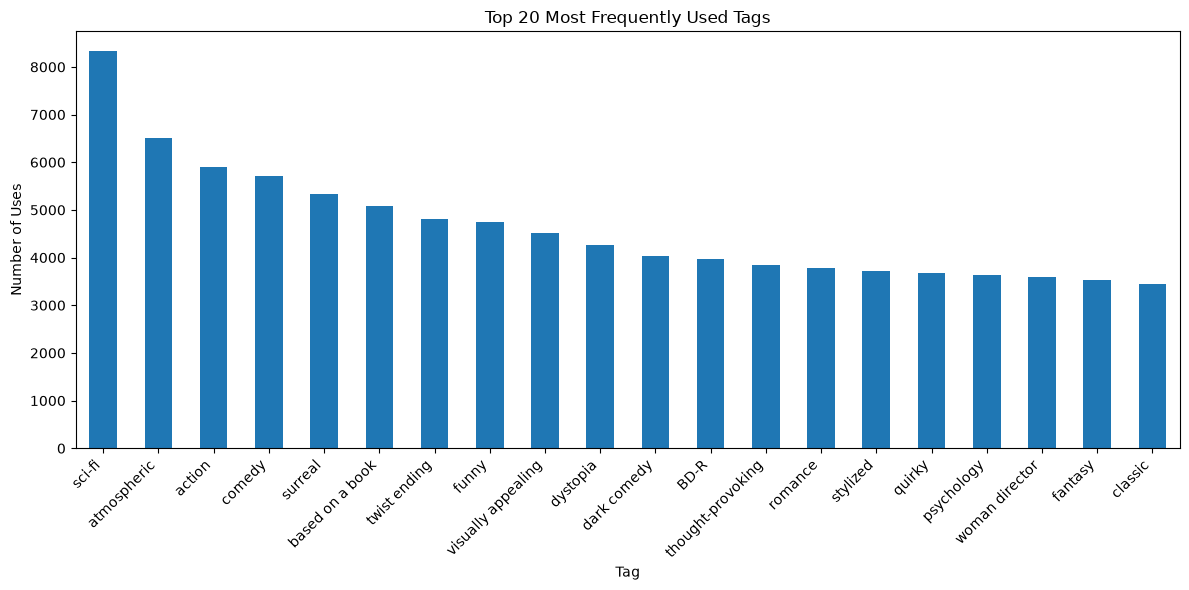

In [52]:
plt.figure(figsize=(12, 6))

top_tags.plot(kind="bar")

plt.title("Top 20 Most Frequently Used Tags")
plt.xlabel("Tag")
plt.ylabel("Number of Uses")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

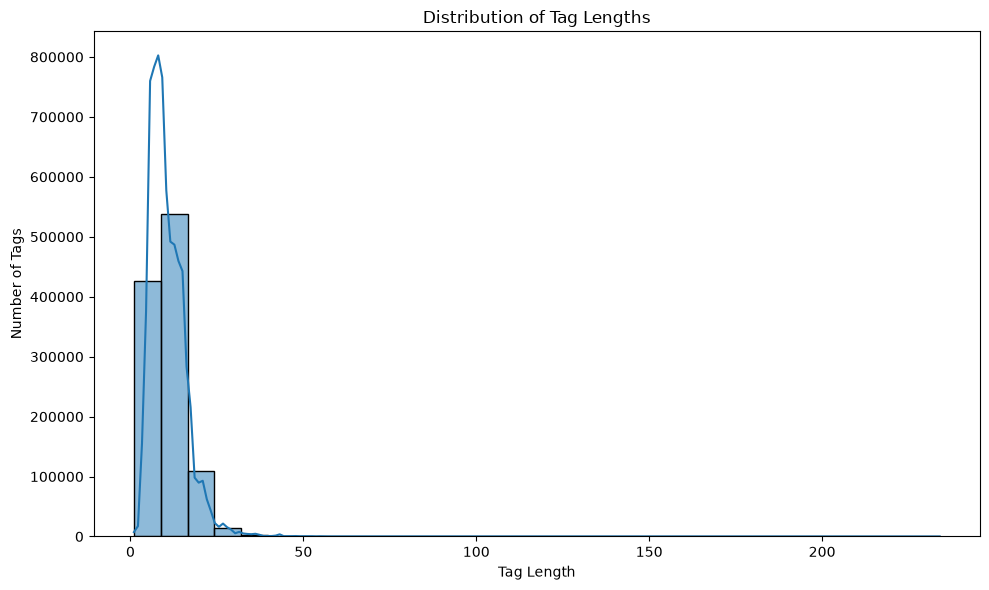

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(tags["tag_length"], bins=30, kde=True)

plt.title("Distribution of Tag Lengths")
plt.xlabel("Tag Length")
plt.ylabel("Number of Tags")
plt.tight_layout()
plt.show()

In [54]:
tags.sort_values("tag_length", ascending=False)[["tag", "tag_length"]].head(10)

,tag,tag_length
891145,den del af filmen hvor han bare går rundt og e...,234.0
891164,den har virkelig mange sjove ting kÃ¸rende for...,230.0
891172,ret interessant billede. Det er utrolig visuel...,229.0
891094,Den fungerer lidt som en kolage som deles ind ...,228.0
891156,"den bliver lidt fantastisk til sidst, når hun ...",216.0
891154,Slutningen er også meget tynd: han får at vide...,215.0
891065,Den har et lidt sjovt sammenfald mellem på en ...,215.0
891107,det bedste ved filmen er ikke de små film han ...,210.0
891169,Nogle af de første scener hvor de to møder hin...,210.0
891170,Den stiller spørgsmålet hvorvidt der er noget ...,209.0


In [55]:
ratings["rating"].describe()

count    1.048575e+06
mean     3.535808e+00
std      1.056276e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [56]:
rating_counts = ratings["rating"].value_counts().sort_index()
rating_counts

rating
0.5     15139
1.0     31975
1.5     17494
2.0     69617
2.5     53093
3.0    207514
3.5    130755
4.0    280291
4.5     90051
5.0    152646
Name: count, dtype: int64

In [ ]:
tags.columns


Index(['tagId,tag'], dtype='str')

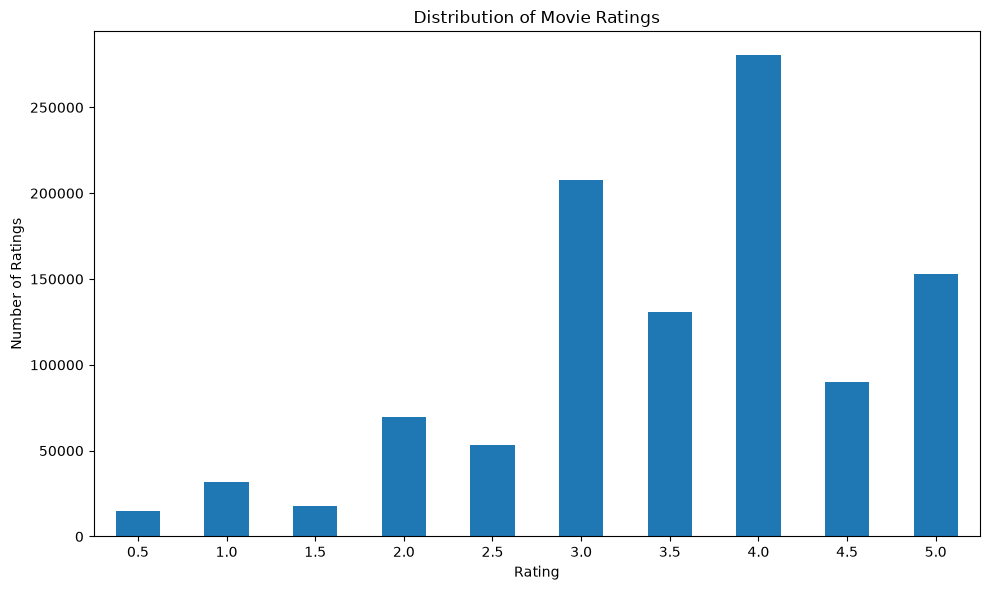

In [57]:
plt.figure(figsize=(10, 6))

rating_counts.plot(kind="bar")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [58]:
movie_avg_rating = ratings.groupby("movieId")["rating"].mean()

movie_avg_rating.head()

movieId
1    3.896957
2    3.305830
3    3.169524
4    2.943299
5    3.133462
Name: rating, dtype: float64

In [59]:
movie_rating_count = ratings.groupby("movieId")["rating"].count()

movie_rating_count.head()

movieId
1    2465
2    1012
3     525
4      97
5     517
Name: rating, dtype: int64

In [60]:
movie_rating_count.sort_values(ascending=False).head(10)

movieId
356     3518
318     3488
296     3418
593     3227
2571    3064
260     2931
480     2745
527     2545
2959    2530
110     2516
Name: rating, dtype: int64

In [61]:
user_rating_count = ratings.groupby("userId")["rating"].count()

user_rating_count.sort_values(ascending=False).head(10)

userId
2177    4227
548     3212
1748    3193
847     2920
2982    2803
5572    2694
3150    2686
5114    2659
997     2371
1920    2328
Name: rating, dtype: int64

In [62]:
user_rating_count.describe()

count    7045.000000
mean      148.839603
std       237.207301
min        20.000000
25%        35.000000
50%        69.000000
75%       156.000000
max      4227.000000
Name: rating, dtype: float64

In [63]:
movie_rating_count.describe()

count    22240.000000
mean        47.148156
std        166.981116
min          1.000000
25%          1.000000
50%          3.000000
75%         20.000000
max       3518.000000
Name: rating, dtype: float64

In [64]:
movie_rating_count.sort_values().head(20)

movieId
206272    1
206208    1
206135    1
206068    1
206024    1
205967    1
205799    1
205661    1
205583    1
205575    1
206523    1
209163    1
144314    1
144312    1
144310    1
144308    1
206861    1
206845    1
206777    1
206727    1
Name: rating, dtype: int64

In [65]:
popular_movies = movie_rating_count[movie_rating_count >= 100]

popular_movies.shape

(2180,)

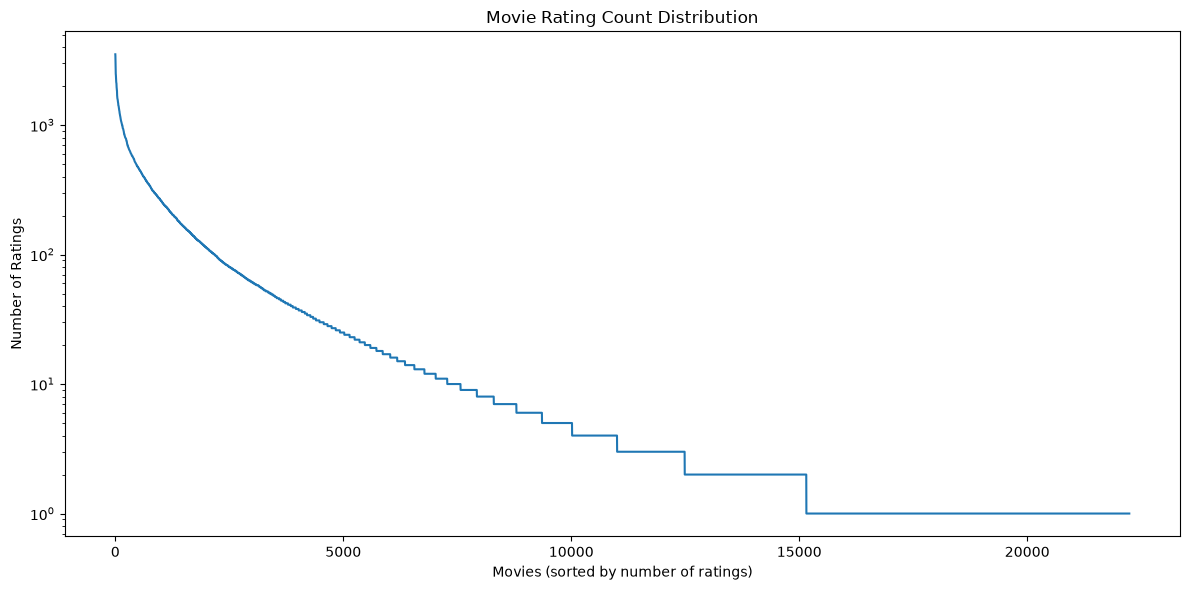

In [66]:
plt.figure(figsize=(12, 6))

movie_rating_count.sort_values(ascending=False).values

plt.plot(movie_rating_count.sort_values(ascending=False).values)

plt.title("Movie Rating Count Distribution")
plt.xlabel("Movies (sorted by number of ratings)")
plt.ylabel("Number of Ratings")
plt.yscale("log")

plt.tight_layout()
plt.show()

In [67]:
user_rating_count.describe()

count    7045.000000
mean      148.839603
std       237.207301
min        20.000000
25%        35.000000
50%        69.000000
75%       156.000000
max      4227.000000
Name: rating, dtype: float64

In [68]:
user_rating_count.idxmax()

np.int64(2177)

In [69]:
user_rating_count.max()

np.int64(4227)

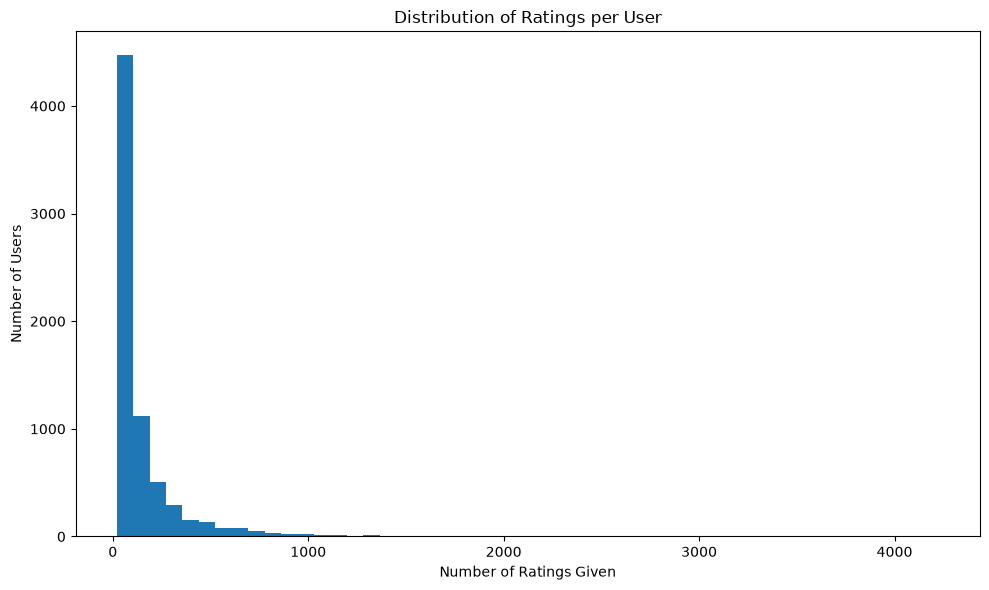

In [70]:
plt.figure(figsize=(10, 6))

plt.hist(user_rating_count, bins=50)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

In [71]:
movie_stats = ratings.groupby("movieId").agg(
    average_rating=("rating", "mean"),
    rating_count=("rating", "count")
)

movie_stats.head()

,average_rating,rating_count
movieId,,
1,3.896957,2465
2,3.305830,1012
3,3.169524,525
4,2.943299,97
5,3.133462,517


In [72]:
well_rated_movies = movie_stats[movie_stats["rating_count"] >= 100]

well_rated_movies.sort_values(
    "average_rating",
    ascending=False
).head(10)

,average_rating,rating_count
movieId,,
318,4.436067,3488
858,4.354253,2175
1221,4.313781,1415
50,4.309235,2393
3435,4.276316,228
527,4.276031,2545
1178,4.251678,149
1264,4.237624,101
1193,4.236370,1504


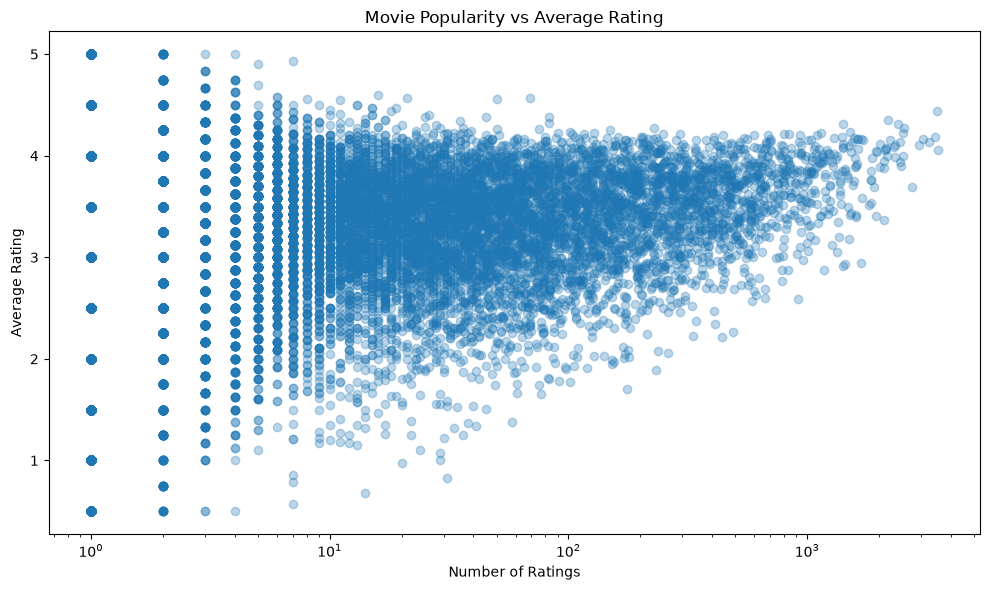

In [73]:

plt.figure(figsize=(10, 6))

plt.scatter(
    movie_stats["rating_count"],
    movie_stats["average_rating"],
    alpha=0.3
)

plt.title("Movie Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.xscale("log")

plt.tight_layout()
plt.show()

In [74]:
movie_stats["rating_count"].corr(
    movie_stats["average_rating"]
)

np.float64(0.10901948311803444)

In [75]:
ratings_movies = ratings.merge(
    movies,
    on="movieId",
    how="left"
)

ratings_movies.head()

,userId,movieId,rating,timestamp,title,genres
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance


In [76]:
ratings_movies.shape

(1048575, 6)

In [77]:
ratings_movies["title"].isnull().sum()

np.int64(0)

In [78]:
genre_ratings = (
    ratings_movies
    .assign(genre=ratings_movies["genres"].str.split("|"))
    .explode("genre")
    .groupby("genre")["rating"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
)

genre_ratings.head(20)

,mean,count
genre,,
Drama,3.687924,456202
Comedy,3.425267,377729
Action,3.462556,312990
Thriller,3.524554,282542
Adventure,3.510994,247048
Romance,3.550223,190849
Sci-Fi,3.476847,181124
Crime,3.690683,173731
Fantasy,3.504684,119778


In [79]:
genre_ratings.index.tolist()

['Drama',
 'Comedy',
 'Action',
 'Thriller',
 'Adventure',
 'Romance',
 'Sci-Fi',
 'Crime',
 'Fantasy',
 'Children',
 'Mystery',
 'Horror',
 'Animation',
 'War',
 'IMAX',
 'Musical',
 'Western',
 'Documentary',
 'Film-Noir',
 '(no genres listed)']

In [80]:
genre_ratings.sort_values("mean", ascending=False).head(15)

,mean,count
genre,,
Film-Noir,3.914308,9785
War,3.798518,52955
Documentary,3.705479,12337
Crime,3.690683,173731
Drama,3.687924,456202
Mystery,3.671652,82845
Animation,3.616119,69941
IMAX,3.592974,44760
Western,3.588718,20430


In [81]:
popular_genres = genre_ratings[genre_ratings["count"] >= 10000]

popular_genres.sort_values("mean", ascending=False)

,mean,count
genre,,
War,3.798518,52955
Documentary,3.705479,12337
Crime,3.690683,173731
Drama,3.687924,456202
Mystery,3.671652,82845
Animation,3.616119,69941
IMAX,3.592974,44760
Western,3.588718,20430
Musical,3.559395,40483


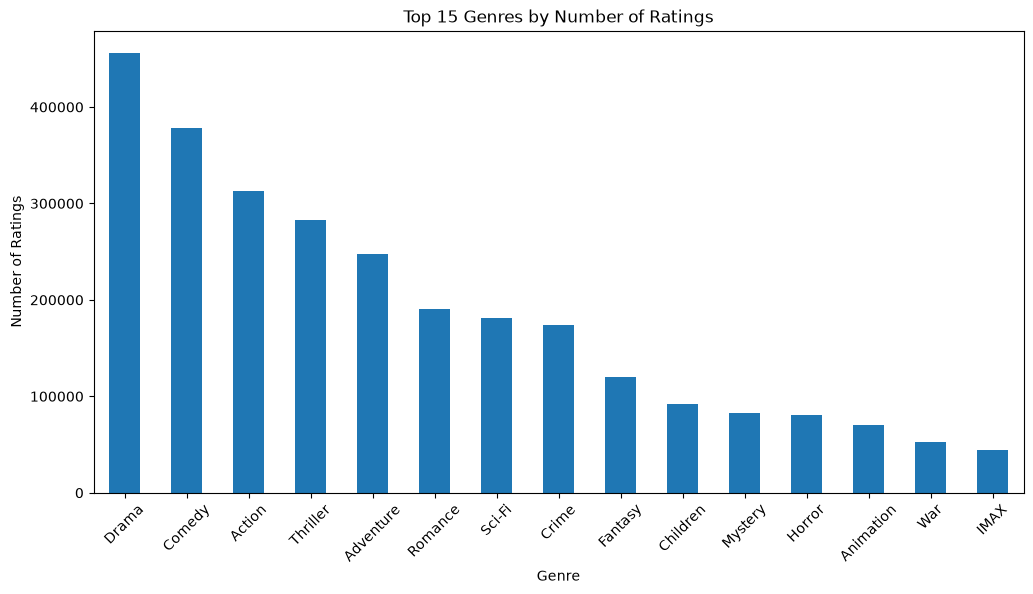

In [82]:
plt.figure(figsize=(12, 6))

genre_ratings.sort_values("count", ascending=False)["count"].head(15).plot(kind="bar")

plt.title("Top 15 Genres by Number of Ratings")
plt.xlabel("Genre")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.show()

In [84]:
tags["tag"] = tags["tag"].fillna("").astype(str)

movie_tags = (
    tags.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)

movie_tags.head()

,movieId,tag
0,1,Owned imdb top 250 Pixar Pixar time travel chi...
1,2,Robin Williams time travel fantasy based on ch...
2,3,funny best friend duringcreditsstinger fishing...
3,4,based on novel or book chick flick divorce int...
4,5,aging baby confidence contraception daughter g...


In [85]:
movie_features = movies.merge(
    movie_tags,
    on="movieId",
    how="left"
)

movie_features.head()

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Owned imdb top 250 Pixar Pixar time travel chi...
1,2,Jumanji (1995),Adventure|Children|Fantasy,Robin Williams time travel fantasy based on ch...
2,3,Grumpier Old Men (1995),Comedy|Romance,funny best friend duringcreditsstinger fishing...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,based on novel or book chick flick divorce int...
4,5,Father of the Bride Part II (1995),Comedy,aging baby confidence contraception daughter g...


In [86]:
movie_features["tag"] = movie_features["tag"].fillna("")

movie_features.isnull().sum()

movieId    0
title      0
genres     0
tag        0
dtype: int64

In [87]:
movie_features["content"] = (
    movie_features["genres"].str.replace("|", " ", regex=False)
    + " "
    + movie_features["tag"]
)

movie_features[["title", "genres", "tag", "content"]].head()

,title,genres,tag,content
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Owned imdb top 250 Pixar Pixar time travel chi...,Adventure Animation Children Comedy Fantasy Ow...
1,Jumanji (1995),Adventure|Children|Fantasy,Robin Williams time travel fantasy based on ch...,Adventure Children Fantasy Robin Williams time...
2,Grumpier Old Men (1995),Comedy|Romance,funny best friend duringcreditsstinger fishing...,Comedy Romance funny best friend duringcredits...
3,Waiting to Exhale (1995),Comedy|Drama|Romance,based on novel or book chick flick divorce int...,Comedy Drama Romance based on novel or book ch...
4,Father of the Bride Part II (1995),Comedy,aging baby confidence contraception daughter g...,Comedy aging baby confidence contraception dau...


In [88]:
movie_features.shape

(62423, 5)

In [89]:
movie_features.to_csv(
    "../data/processed/movie_features.csv",
    index=False
)

In [90]:
import os

os.path.exists("../data/processed/movie_features.csv")

True

In [91]:
saved_movie_features = pd.read_csv(
    "../data/processed/movie_features.csv"
)

saved_movie_features.shape

(62423, 5)

In [2]:
import sys
sys.path.append("../")

%load_ext autoreload
%autoreload 2

from src.data.load import load_movies, load_tags
from src.data.preprocessing import build_movie_features

movies_raw = load_movies()
tags_raw = load_tags()

rebuilt_features = build_movie_features(movies_raw, tags_raw)

rebuilt_features.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,movieId,title,genres,tag,content,weighted_content
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Owned imdb top 250 Pixar Pixar time travel chi...,Adventure Animation Children Comedy Fantasy Ow...,Adventure Animation Children Comedy Fantasy Ad...
1,2,Jumanji (1995),Adventure|Children|Fantasy,Robin Williams time travel fantasy based on ch...,Adventure Children Fantasy Robin Williams time...,Adventure Children Fantasy Adventure Children ...
2,3,Grumpier Old Men (1995),Comedy|Romance,funny best friend duringcreditsstinger fishing...,Comedy Romance funny best friend duringcredits...,Comedy Romance Comedy Romance funny best frien...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,based on novel or book chick flick divorce int...,Comedy Drama Romance based on novel or book ch...,Comedy Drama Romance Comedy Drama Romance base...
4,5,Father of the Bride Part II (1995),Comedy,aging baby confidence contraception daughter g...,Comedy aging baby confidence contraception dau...,Comedy Comedy aging baby confidence contracept...


In [4]:
from src.data.preprocessing import save_movie_features

save_movie_features(rebuilt_features, "../data/processed/movie_features.csv")
print("Saved.")

Saved.
